# Week 2 — AMS-02 Multi-Subsystem PID

This notebook builds a **simulated AMS-02** pipeline:

- `AMS02Simulator` orchestrates detector subsystems
- Subsystem classes: `TrackerModel`, `TOFModel`, `RICHModel`, `TRDModel`, `ECALModel`
- `DatasetBuilder` generates a tabular dataset
- `PIDTrainer` trains a baseline classifier

Species covered: `e-`, `e+`, `p`, `He`, `C`, `O`, `Si`, `Fe`


In [2]:
# --- Setup ---
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
print('OK')


OK


## 1) Species and kinematics

We use the relations:

- Rigidity: **$R = p/Z$** (in GV)
- Approximate momentum: **$p ≈ |Z|·R$** (GeV/c)
- **$β = p / \sqrt(p² + m²)$**

Nuclear mass is approximated as **$A·m_p$**.


In [3]:
@dataclass(frozen=True)
class Species:
    label: str
    Z: int
    A: int
    charge_sign: int  # -1 or +1
    is_lepton: bool


class Kinematics:
    """Kinematics helper."""
    m_p_GeV = 0.9382720813
    m_e_GeV = 0.00051099895

    @classmethod
    def mass_GeV(cls, s: Species) -> float:
        return cls.m_e_GeV if s.is_lepton else s.A * cls.m_p_GeV

    @classmethod
    def beta_from_rigidity(cls, R_GV: float, s: Species) -> float:
        p = abs(s.Z) * R_GV
        m = cls.mass_GeV(s)
        return float(p / math.sqrt(p*p + m*m))


SPECIES: List[Species] = [
    Species('e-', 1, 0, -1, True),
    Species('e+', 1, 0, +1, True),
    Species('p',  1, 1, +1, False),
    Species('He', 2, 4, +1, False),
    Species('C',  6, 12, +1, False),
    Species('O',  8, 16, +1, False),
    Species('Si', 14, 28, +1, False),
    Species('Fe', 26, 56, +1, False),
]
SPECIES_BY_LABEL = {s.label: s for s in SPECIES}

for lab in ['e-', 'p', 'He', 'Fe']:
    s = SPECIES_BY_LABEL[lab]
    print(lab, 'beta at R=10 GV:', Kinematics.beta_from_rigidity(10.0, s))


e- beta at R=10 GV: 0.9999999986944005
p beta at R=10 GV: 0.9956270793209386
He beta at R=10 GV: 0.9828446860913361
Fe beta at R=10 GV: 0.9801848579964545


## 2) Base utilities


In [4]:
class RNG:
    def __init__(self, rng: Optional[np.random.Generator] = None):
        self.rng = rng if rng is not None else np.random.default_rng()

    def smear_gauss(self, x: float, sigma: float) -> float:
        return float(x + self.rng.normal(0.0, sigma))

    @staticmethod
    def clamp01(x: float) -> float:
        return float(min(1.0, max(0.0, x)))


## 3) Subsystem models

Each subsystem returns a dictionary of observable(s).
Can later swap any of these with more realistic models (e.g., using Week 1 tracker resolution curves).


In [5]:
class TrackerModel(RNG):
    """Simulated tracker: measures rigidity and charge proxy."""

    def sigma_R(self, R_GV: float) -> float:
        # relative resolution grows with R (tunable)
        rel = 0.01 + 0.00035 * R_GV
        return rel * R_GV

    def measure(self, s: Species, R_true: float) -> Dict[str, float]:
        R_meas = self.smear_gauss(R_true, self.sigma_R(R_true))
        #charge improves with sqrt(Z)
        sigmaZ = 0.25 / math.sqrt(max(1, s.Z))
        Z_meas = self.smear_gauss(s.Z, sigmaZ)
        return {'R_tracker': R_meas, 'Z_trk': Z_meas}


class TOFModel(RNG):
    """TOF: coarse beta and charge proxy."""

    def measure(self, s: Species, beta_true: float) -> Dict[str, float]:
        beta = self.smear_gauss(beta_true, 0.02)
        beta = float(min(0.999999, max(0.0, beta)))
        sigmaZ = 0.35 / math.sqrt(max(1, s.Z))
        Z = self.smear_gauss(s.Z, sigmaZ)
        return {'beta_tof': beta, 'Z_tof': Z}


class RICHModel(RNG):
    """RICH: precise beta and better charge proxy."""

    def measure(self, s: Species, beta_true: float) -> Dict[str, float]:
        sigma_beta = 0.0015 / math.sqrt(max(1, s.Z))
        beta = self.smear_gauss(beta_true, sigma_beta)
        beta = float(min(0.999999, max(0.0, beta)))
        sigmaZ = 0.18 / math.sqrt(max(1, s.Z))
        Z = self.smear_gauss(s.Z, sigmaZ)
        return {'beta_rich': beta, 'Z_rich': Z}


class TRDModel(RNG):
    """TRD: e-likeness score in [0, 1]."""

    def measure(self, s: Species, R_true: float) -> Dict[str, float]:
        if s.is_lepton:
            mu = 0.75 + 0.15 * (1.0 - math.exp(-R_true / 20.0))
            sig = 0.08
        else:
            mu = 0.15 + 0.05 * math.exp(-R_true / 30.0)
            sig = 0.07
        score = self.clamp01(self.smear_gauss(mu, sig))
        return {'TRD_e_like': score}


class ECALModel(RNG):
    """ECAL: E, E/p, shower shape score."""

    def measure(self, s: Species, R_true: float) -> Dict[str, float]:
        p = abs(s.Z) * R_true
        if s.is_lepton:
            e_over_p = self.clamp01(self.smear_gauss(1.0, 0.06))
            shower = self.clamp01(self.smear_gauss(0.85, 0.08))
            E = p * self.smear_gauss(1.0, 0.07)
        else:
            e_over_p = self.clamp01(self.smear_gauss(0.45, 0.18))
            shower = self.clamp01(self.smear_gauss(0.20, 0.12))
            E = p * e_over_p * self.smear_gauss(1.0, 0.15)
        return {'E_ecal': float(E), 'E_over_p': float(e_over_p), 'shower_shape': float(shower)}


## 4) AMS-02 simulator


In [6]:
class AMS02Simulator:
    """Coordinates subsystem models to produce one synthetic event."""

    def __init__(
        self,
        tracker: TrackerModel,
        tof: TOFModel,
        rich: RICHModel,
        trd: TRDModel,
        ecal: ECALModel,
    ):
        self.tracker = tracker
        self.tof = tof
        self.rich = rich
        self.trd = trd
        self.ecal = ecal

    def simulate_event(self, s: Species, R_true: float) -> Dict[str, float]:
        beta_true = Kinematics.beta_from_rigidity(R_true, s)

        row: Dict[str, float] = {
            'label': s.label,
            'Z_true': float(s.Z),
            'A_true': float(s.A),
            'sign': float(s.charge_sign),
            'R_true': float(R_true),
            'beta_true': float(beta_true),
        }

        row.update(self.tracker.measure(s, R_true))
        row.update(self.tof.measure(s, beta_true))
        row.update(self.rich.measure(s, beta_true))
        row.update(self.trd.measure(s, R_true))
        row.update(self.ecal.measure(s, R_true))

        return row


# Instantiate simulator with a shared RNG so runs are reproducible
tracker = TrackerModel(rng)
tof = TOFModel(rng)
rich = RICHModel(rng)
trd = TRDModel(rng)
ecal = ECALModel(rng)

sim = AMS02Simulator(tracker, tof, rich, trd, ecal)
print(sim.simulate_event(SPECIES_BY_LABEL['He'], 30.0))


{'label': 'He', 'Z_true': 2.0, 'A_true': 4.0, 'sign': 1.0, 'R_true': 30.0, 'beta_true': 0.9980493789339133, 'R_tracker': 30.187401004048976, 'Z_trk': 1.8161550465377787, 'beta_tof': 0.999999, 'Z_tof': 2.2327778911867604, 'beta_rich': 0.9959799936155672, 'Z_rich': 1.83425960726759, 'TRD_e_like': 0.1773428002802821, 'E_ecal': 20.566777589339203, 'E_over_p': 0.39307633337815523, 'shower_shape': 0.19798386109948535}


## 5) Dataset builder

We sample a rigidity from a log-uniform prior for now.
Later can replace this with a power-law per species.


In [7]:
class DatasetBuilder:
    def __init__(self, simulator: AMS02Simulator, rng: Optional[np.random.Generator] = None):
        self.sim = simulator
        self.rng = rng if rng is not None else np.random.default_rng()

    def sample_rigidity(self, n: int, Rmin: float = 1.0, Rmax: float = 300.0) -> np.ndarray:
        u = self.rng.uniform(np.log(Rmin), np.log(Rmax), size=n)
        return np.exp(u)

    def sample_labels(self, n: int, class_priors: Optional[Dict[str, float]] = None) -> np.ndarray:
        labels = [s.label for s in SPECIES]
        if class_priors is None:
            p = None
        else:
            p = np.array([class_priors.get(lab, 0.0) for lab in labels], dtype=float)
            p = p / p.sum()
        return self.rng.choice(labels, size=n, replace=True, p=p)

    def build(self, n: int = 40000, Rmin: float = 1.0, Rmax: float = 300.0,
              class_priors: Optional[Dict[str, float]] = None) -> pd.DataFrame:
        chosen = self.sample_labels(n, class_priors)
        Rvals = self.sample_rigidity(n, Rmin=Rmin, Rmax=Rmax)
        rows = []
        for lab, R in zip(chosen, Rvals):
            s = SPECIES_BY_LABEL[str(lab)]
            rows.append(self.sim.simulate_event(s, float(R)))
        return pd.DataFrame(rows)


builder = DatasetBuilder(sim, rng=rng)
df = builder.build(n=40000)
df.head()


,label,Z_true,A_true,sign,R_true,beta_true,R_tracker,Z_trk,beta_tof,Z_tof,beta_rich,Z_rich,TRD_e_like,E_ecal,E_over_p,shower_shape
0,C,6.0,12.0,1.0,12.344100,0.988642,12.300728,5.883835,0.998476,5.850324,0.988604,5.966569,0.219395,30.030738,0.348982,0.116464
1,p,1.0,1.0,1.0,135.038474,0.999976,137.273729,1.007060,0.961477,1.217641,0.999270,1.050114,0.021454,65.181348,0.499899,0.223173
2,e+,1.0,0.0,1.0,7.917813,1.000000,7.828217,1.291511,0.985069,1.318570,0.999999,0.850200,0.858882,7.399095,0.974218,0.901082
3,Fe,26.0,56.0,1.0,17.698887,0.993544,17.665897,26.003778,0.992956,26.026166,0.993306,25.980501,0.227686,151.086726,0.375778,0.140327
4,Si,14.0,28.0,1.0,1.130975,0.516189,1.125566,13.931377,0.530775,13.957994,0.515754,13.990226,0.100396,3.921269,0.295961,0.362539


In [8]:
print(df['label'].value_counts())


label
e+    5087
O     5042
C     5037
e-    5000
p     4989
Fe    4987
Si    4941
He    4917
Name: count, dtype: int64


### Save .csv

In [9]:
from pathlib import Path

PROJECT_ROOT = Path("../../").resolve()

DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures/week2"

DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

In [10]:
dataset_path = DATA_DIR / "ams_week2_pid_dataset.csv"
df.to_csv(dataset_path, index=False)

print(f"Saved dataset to: {dataset_path.resolve()}")
print(df.shape)
df.head()

Saved dataset to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\data\ams_week2_pid_dataset.csv
(40000, 16)


,label,Z_true,A_true,sign,R_true,beta_true,R_tracker,Z_trk,beta_tof,Z_tof,beta_rich,Z_rich,TRD_e_like,E_ecal,E_over_p,shower_shape
0,C,6.0,12.0,1.0,12.344100,0.988642,12.300728,5.883835,0.998476,5.850324,0.988604,5.966569,0.219395,30.030738,0.348982,0.116464
1,p,1.0,1.0,1.0,135.038474,0.999976,137.273729,1.007060,0.961477,1.217641,0.999270,1.050114,0.021454,65.181348,0.499899,0.223173
2,e+,1.0,0.0,1.0,7.917813,1.000000,7.828217,1.291511,0.985069,1.318570,0.999999,0.850200,0.858882,7.399095,0.974218,0.901082
3,Fe,26.0,56.0,1.0,17.698887,0.993544,17.665897,26.003778,0.992956,26.026166,0.993306,25.980501,0.227686,151.086726,0.375778,0.140327
4,Si,14.0,28.0,1.0,1.130975,0.516189,1.125566,13.931377,0.530775,13.957994,0.515754,13.990226,0.100396,3.921269,0.295961,0.362539


## 6) PID trainer


In [11]:
class PIDTrainer:
    def __init__(self, features: List[str]):
        self.features = features
        self.model = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )

    def fit(self, df: pd.DataFrame, label_col: str = 'label'):
        X = df[self.features]
        y = df[label_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        self.model.fit(X_train, y_train)
        pred = self.model.predict(X_test)

        return X_test, y_test, pred

    def feature_importance(self) -> pd.Series:
        return pd.Series(self.model.feature_importances_, index=self.features).sort_values(ascending=False)


FEATURES = [
    'R_tracker', 'Z_trk',
    'beta_tof', 'Z_tof',
    'beta_rich', 'Z_rich',
    'TRD_e_like',
    'E_over_p', 'shower_shape',
]

trainer = PIDTrainer(FEATURES)
X_test, y_test, pred = trainer.fit(df)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           C       1.00      1.00      1.00      1259
          Fe       1.00      1.00      1.00      1247
          He       1.00      1.00      1.00      1229
           O       1.00      1.00      1.00      1261
          Si       1.00      1.00      1.00      1235
          e+       0.50      0.52      0.51      1272
          e-       0.49      0.46      0.48      1250
           p       1.00      1.00      1.00      1247

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



### Grouped Models

In [12]:
FEATURE_GROUPS = {
    "tracker_only": [
        "R_tracker", "Z_trk"
    ],
    "tracker_velocity": [
        "R_tracker", "Z_trk",
        "beta_tof", "beta_rich", "Z_tof", "Z_rich"
    ],
    "tracker_leptonID": [
        "R_tracker", "Z_trk",
        "TRD_e_like", "E_over_p", "shower_shape"
    ],
    "full_system": [
        "R_tracker", "Z_trk",
        "beta_tof", "beta_rich", "Z_tof", "Z_rich",
        "TRD_e_like", "E_over_p", "shower_shape"
    ]
}

for k, v in FEATURE_GROUPS.items():
    print(f"{k}: {v}")

tracker_only: ['R_tracker', 'Z_trk']
tracker_velocity: ['R_tracker', 'Z_trk', 'beta_tof', 'beta_rich', 'Z_tof', 'Z_rich']
tracker_leptonID: ['R_tracker', 'Z_trk', 'TRD_e_like', 'E_over_p', 'shower_shape']
full_system: ['R_tracker', 'Z_trk', 'beta_tof', 'beta_rich', 'Z_tof', 'Z_rich', 'TRD_e_like', 'E_over_p', 'shower_shape']


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

results = []
trained_models = {}

for group_name, features in FEATURE_GROUPS.items():

    trainer = PIDTrainer(features)

    X_test, y_test, pred = trainer.fit(df)

    acc = accuracy_score(y_test, pred)

    results.append({
        "model": group_name,
        "n_features": len(features),
        "accuracy": acc
    })

    trained_models[group_name] = {
        "trainer": trainer,
        "X_test": X_test,
        "y_test": y_test,
        "pred": pred,
        "features": features
    }

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)

results_df

,model,n_features,accuracy
2,tracker_leptonID,5,0.8713
3,full_system,9,0.8703
1,tracker_velocity,6,0.8087
0,tracker_only,2,0.7476


### Rigidity accuracy comparison

In [14]:
rigidity_bins = [0, 10, 30, 100, 300, 1000]
rigidity_bin_labels = ["0–10", "10–30", "30–100", "100–300", "300–1000"]

rigidity_bins, rigidity_bin_labels

([0, 10, 30, 100, 300, 1000],
 ['0–10', '10–30', '30–100', '100–300', '300–1000'])

In [15]:
rigidity_results = []

for model_name, info in trained_models.items():
    X_test = info["X_test"]
    y_test = info["y_test"]
    pred = info["pred"]

    # use true rigidity if available; if not, switch to R_tracker
    test_rigidity = df.loc[X_test.index, "R_true"]

    rig_bin = pd.cut(
        test_rigidity,
        bins=rigidity_bins,
        labels=rigidity_bin_labels,
        include_lowest=True
    )

    temp = pd.DataFrame({
        "R_true": test_rigidity,
        "rigidity_bin": rig_bin,
        "y_true": y_test.values,
        "y_pred": pred
    })

    for bin_label in rigidity_bin_labels:
        sub = temp[temp["rigidity_bin"] == bin_label]

        if len(sub) == 0:
            acc = np.nan
            n_events = 0
        else:
            acc = accuracy_score(sub["y_true"], sub["y_pred"])
            n_events = len(sub)

        rigidity_results.append({
            "model": model_name,
            "rigidity_bin": bin_label,
            "accuracy": acc,
            "n_events": n_events
        })

rigidity_results_df = pd.DataFrame(rigidity_results)
rigidity_results_df

,model,rigidity_bin,accuracy,n_events
0,tracker_only,0–10,0.752097,4054
1,tracker_only,10–30,0.757447,1880
2,tracker_only,30–100,0.742883,2213
3,tracker_only,100–300,0.733405,1853
4,tracker_only,300–1000,NaN,0
5,tracker_velocity,0–10,0.873705,4054
6,tracker_velocity,10–30,0.795213,1880
7,tracker_velocity,30–100,0.754632,2213
8,tracker_velocity,100–300,0.744738,1853
9,tracker_velocity,300–1000,NaN,0


### Plots

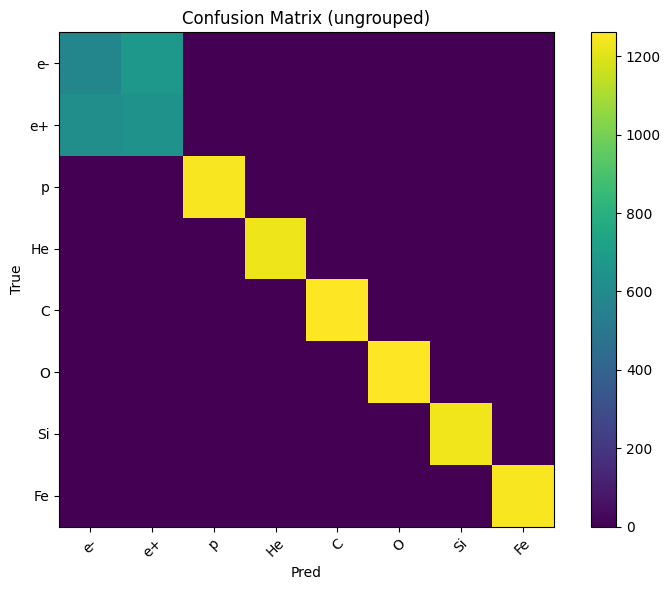

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_confusion_matrix.png


In [16]:
labels = [s.label for s in SPECIES]
cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix (ungrouped)')
plt.colorbar()
ticks = np.arange(len(labels))
plt.xticks(ticks, labels, rotation=45)
plt.yticks(ticks, labels)
plt.ylabel('True')
plt.xlabel('Pred')
plt.tight_layout()

cm_path = FIG_DIR / "week2_pid_confusion_matrix.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {cm_path.resolve()}")

Z_rich          0.277561
Z_trk           0.260028
Z_tof           0.236815
TRD_e_like      0.088499
shower_shape    0.066836
E_over_p        0.029746
R_tracker       0.016832
beta_rich       0.013392
beta_tof        0.010291
dtype: float64


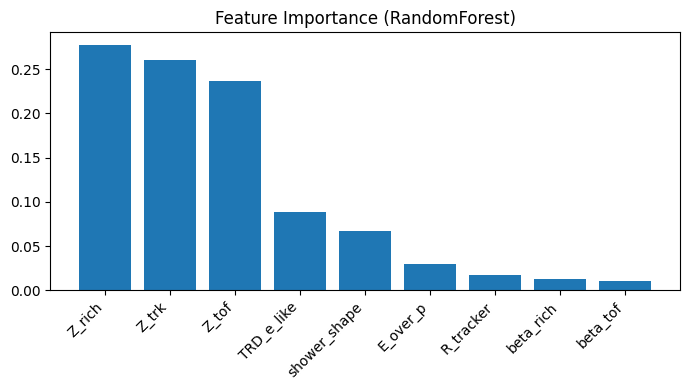

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_feature_importance.png


In [17]:
imp = trainer.feature_importance()
print(imp)

plt.figure(figsize=(7, 4))
plt.bar(imp.index, imp.values)
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance (RandomForest)')
plt.tight_layout()

fi_path = FIG_DIR / "week2_pid_feature_importance.png"
plt.savefig(fi_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fi_path.resolve()}")

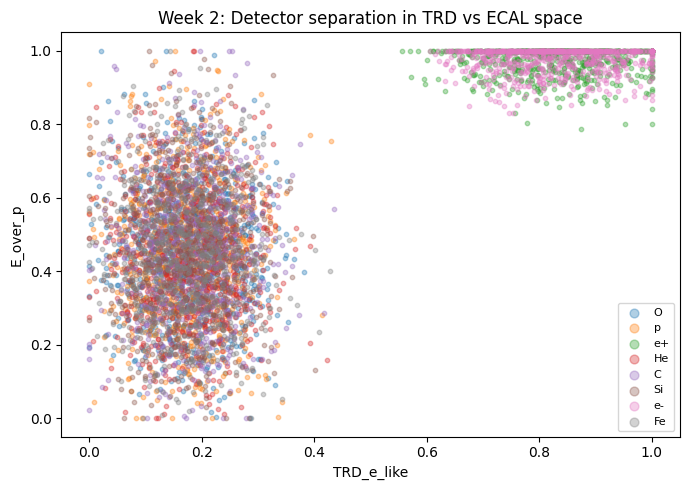

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_trd_ecal_scatter.png


In [18]:
plt.figure(figsize=(7, 5))

sample_df = df.sample(min(len(df), 6000), random_state=42)

for label in sample_df["label"].unique():
    sub = sample_df[sample_df["label"] == label]
    plt.scatter(
        sub["TRD_e_like"],
        sub["E_over_p"],
        s=10,
        alpha=0.35,
        label=label
    )

plt.xlabel("TRD_e_like")
plt.ylabel("E_over_p")
plt.title("Week 2: Detector separation in TRD vs ECAL space")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()

sep_path = FIG_DIR / "week2_pid_trd_ecal_scatter.png"
plt.savefig(sep_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {sep_path.resolve()}")

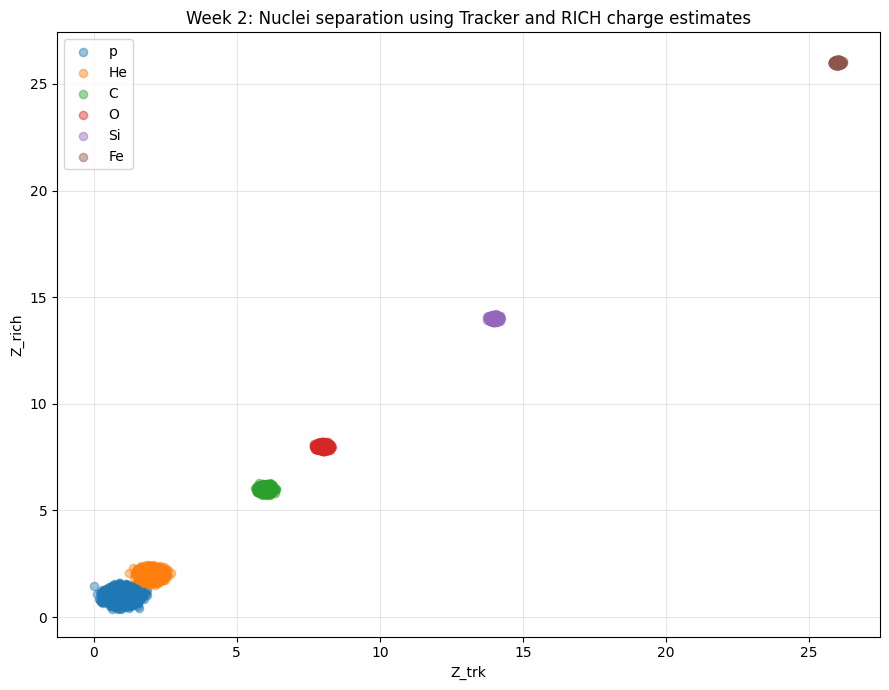

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_nuclei_separation.png


In [19]:
# keep only nuclei (exclude electrons / positrons)
nuclei_labels = ["p", "He", "C", "O", "Si", "Fe"]
df_nuc = df[df["label"].isin(nuclei_labels)].copy()

# -----------------------------
# 1) Tracker vs RICH charge
# -----------------------------
plt.figure(figsize=(9, 7))

for label in nuclei_labels:
    sub = df_nuc[df_nuc["label"] == label]
    plt.scatter(
        sub["Z_trk"],
        sub["Z_rich"],
        s=35,
        alpha=0.45,
        label=label
    )

plt.xlabel("Z_trk")
plt.ylabel("Z_rich")
plt.title("Week 2: Nuclei separation using Tracker and RICH charge estimates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

nuc_path = FIG_DIR / "week2_pid_nuclei_separation.png"
plt.savefig(nuc_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {nuc_path.resolve()}")

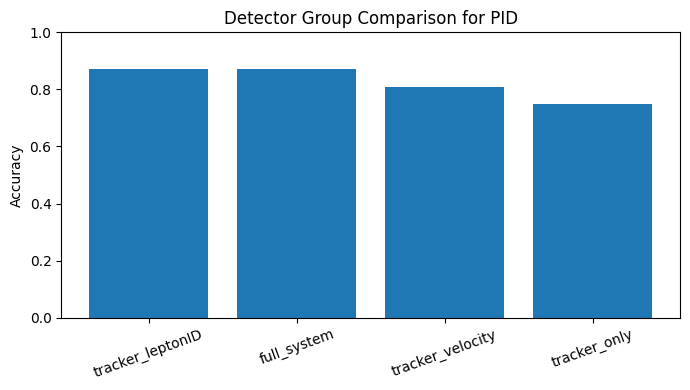

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_grouped_comparison.png


In [20]:
plt.figure(figsize=(7,4))

plt.bar(results_df["model"], results_df["accuracy"])

plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Detector Group Comparison for PID")

plt.xticks(rotation=20)

plt.tight_layout()
grouped_path = FIG_DIR / "week2_pid_grouped_comparison.png"
plt.savefig(grouped_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {grouped_path.resolve()}")

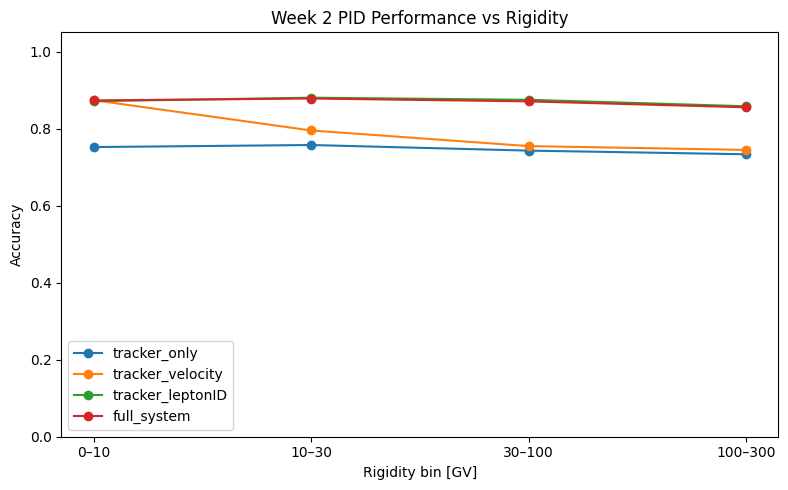

Saved: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_accuracy_vs_rigidity.png


In [21]:
plt.figure(figsize=(8,5))

for model_name in rigidity_results_df["model"].unique():
    sub = rigidity_results_df[rigidity_results_df["model"] == model_name]
    plt.plot(
        sub["rigidity_bin"],
        sub["accuracy"],
        marker="o",
        label=model_name
    )

plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.xlabel("Rigidity bin [GV]")
plt.title("Week 2 PID Performance vs Rigidity")
plt.legend()
plt.tight_layout()

rigidity_plot_path = FIG_DIR / "week2_pid_accuracy_vs_rigidity.png"
plt.savefig(rigidity_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", rigidity_plot_path)

In [22]:
rigidity_table_path = DATA_DIR / "week2_pid_accuracy_vs_rigidity.csv"
rigidity_results_df.to_csv(rigidity_table_path, index=False)

print("Saved:", rigidity_table_path)

Saved: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\data\week2_pid_accuracy_vs_rigidity.csv


### Confusion Matrix Comparison

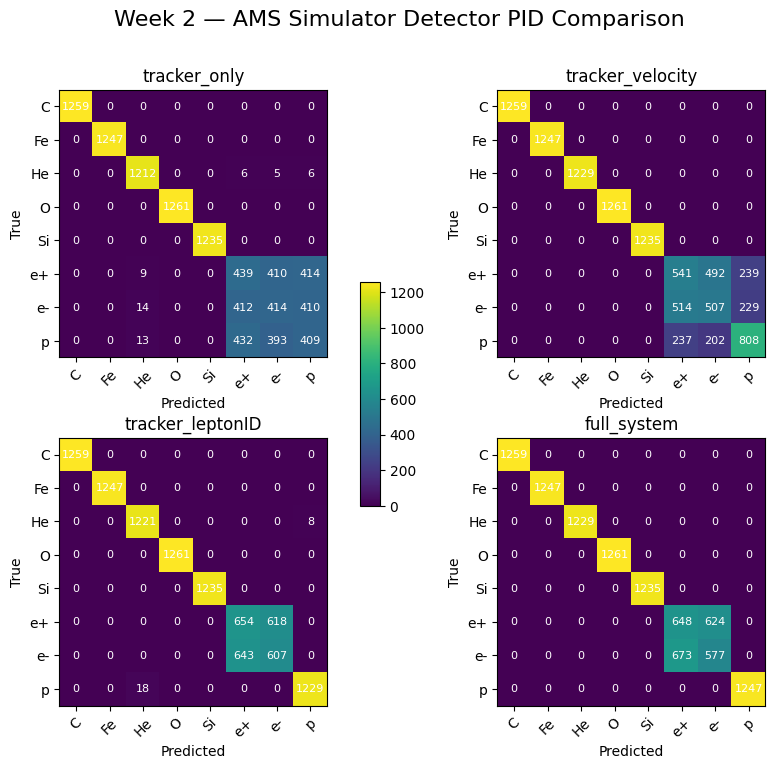

In [23]:
labels = sorted(df["label"].unique())

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

im = None

for ax, (model_name, info) in zip(axes, trained_models.items()):

    cm = confusion_matrix(info["y_test"], info["pred"], labels=labels)

    im = ax.imshow(cm)

    ax.set_title(model_name)

    ticks = np.arange(len(labels))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # numbers in cells
    for (j,k), val in np.ndenumerate(cm):
        ax.text(k, j, int(val), ha='center', va='center', color='white', fontsize=8)

    ax.set_aspect('equal')

# tighten matrix spacing
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# create a thin colorbar axis manually in the middle
cax = fig.add_axes([0.46, 0.36, 0.02, 0.28])
fig.colorbar(im, cax=cax)

fig.suptitle("Week 2 — AMS Simulator Detector PID Comparison", fontsize=16)

save_path = FIG_DIR / "week2_confusion_matrix_lattice.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

## Week 2 Interpretation

The simulated PID task shows the basic AMS-02 logic clearly:

- The **Tracker** provides rigidity and charge-related observables.
- **TOF** and **RICH** provide velocity measurements, with RICH being much more precise.
- The **TRD** strongly separates leptons from hadrons through an electron-likeness response.
- The **ECAL** separates electromagnetic and hadronic behavior through \(E/p\) and shower shape.

The classifier performs well not because of a single detector, but because AMS-style PID is inherently **redundant**.

In this toy model, the strongest separation is expected from:
1. `TRD_e_like`
2. `E_over_p`
3. `shower_shape`
4. charge-related observables
5. precise velocity measurements

This completes Week 2 as a simplified multi-detector PID study.